# Session 7: Image Segmentation


- Ex7_1: Global threshold Manually vs Automatically
- Ex7_2: Global vs Adaptive Local Thresholding
- Ex7_3: Region labelling

In [1]:
# connect GG Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# load packages
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Create a link to Session folder
PATH = '/content/drive/MyDrive/IVP/Session_07/'

# Font size for figures
FS = 12

Threshold value by Otsu method:  168


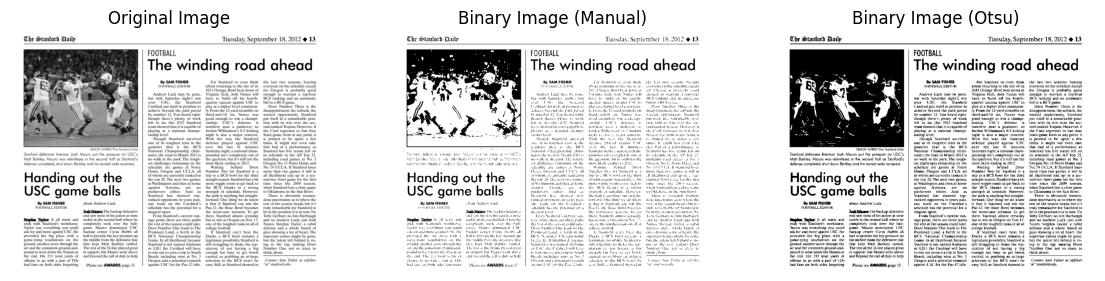

In [4]:
#Ex7_1: Global threshold Manually vs Automatically
Img = cv2.imread(PATH + 'news.png', cv2.IMREAD_GRAYSCALE)

# Convert form GRAYSCALE to BINARY

# a. Manually choose a threshold
# Pixels > 100 are set to 255 (white)
# Pixels <= 100 are set to 0 (black)
_, Img_bw1 = cv2.threshold(Img, 100, 255, cv2.THRESH_BINARY)

# b. Automatically choose a threshold
# THRESH_BINARY applies binary thresholding using the threshold found by Otsu
thres_val, Img_bw2 = cv2.threshold(Img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Threshold value by Otsu method: {thres_val: .0f}')

plt.figure(figsize=(14, 10))

plt.subplot(1, 3, 1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS)
plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(Img_bw1, cmap='gray'), plt.title('Binary Image (Manual)', fontsize=FS)
plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(Img_bw2, cmap='gray'), plt.title('Binary Image (Otsu)', fontsize=FS)
plt.axis('off')
plt.savefig(PATH + 'Ex7_1.jpg', dpi=400)
plt.show()

(1556, 1159)


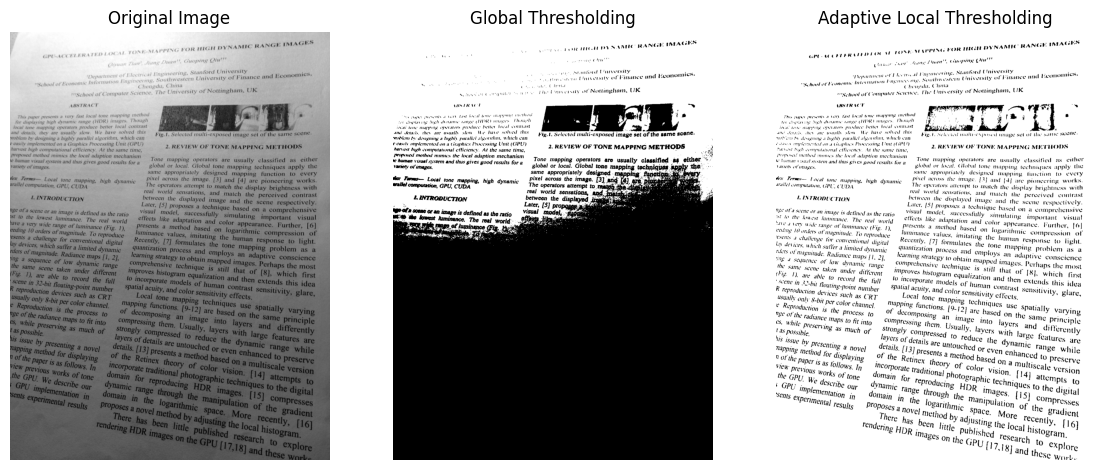

In [5]:
#Ex7_2: Global vs Adaptive Local Thresholding
Img = cv2.imread(PATH + 'paper.png', cv2.IMREAD_GRAYSCALE)
#check image dimensions
print(Img.shape)

# Global thresholding
# A single threshold value is computed and applied to the entire image.
_, Img_global = cv2.threshold(Img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adpative local thresholding
# Threshold is computed for each pixel based on its local neighborhood
Img_local = cv2.adaptiveThreshold(Img,
                                  255,
                                  cv2.ADAPTIVE_THRESH_MEAN_C, # Use mean of local neighborhood
                                  cv2.THRESH_BINARY,
                                  51,                         # Blocksize
                                  38                          # C: the constant subtracted
                                  )

plt.figure(figsize=(14, 10))

plt.subplot(1, 3, 1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS)
plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(Img_global, cmap='gray'), plt.title('Global Thresholding', fontsize=FS)
plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(Img_local, cmap='gray'), plt.title('Adaptive Local Thresholding', fontsize=FS)
plt.axis('off')
plt.savefig(PATH + 'Ex7_2.jpg', dpi=400)
plt.show()

Number of fishes: 20


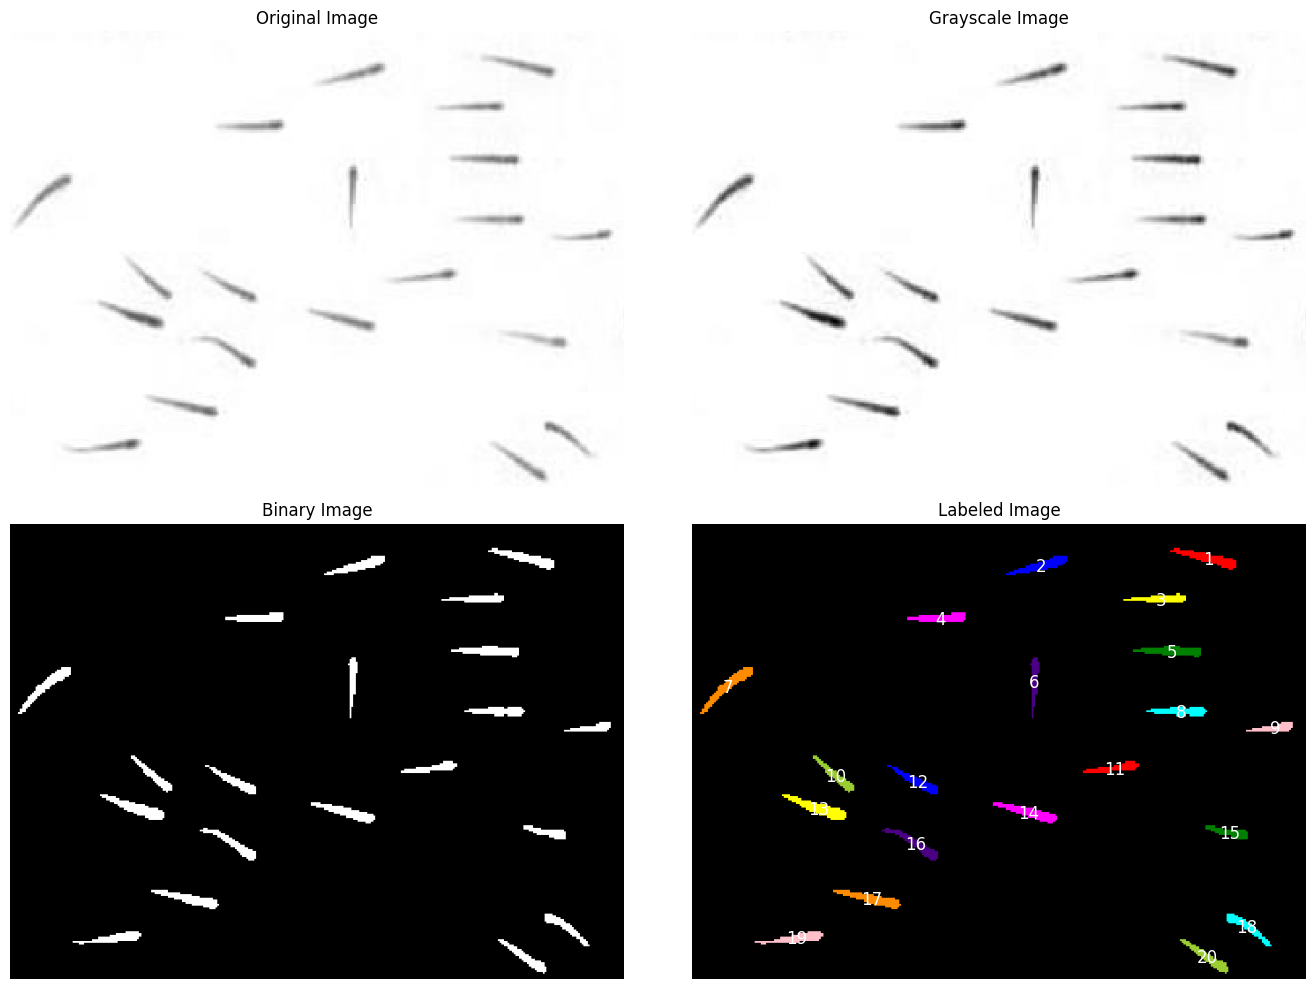

In [6]:
from skimage.measure import label, regionprops
from skimage.color import label2rgb

#Ex7_3: Region labelling
Img = cv2.imread(PATH + 'fish.png', cv2.IMREAD_COLOR_RGB)

# Convert from RGB to GRAYSCALE
Img_gray = cv2.cvtColor(Img, cv2.COLOR_RGB2GRAY)

# Convert from GRAYSCALE to BINARY using Otsu method
_, Img_bw = cv2.threshold(Img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Label regions in the binary image

# Assign a unique label to each connected foreground region
L = label(Img_bw, connectivity=2)

# Extract properties of each labeled region
fishes = regionprops(L)

# Count detected fish objects
print(f'Number of fishes: {len(fishes)}')

# Generate a color visualization of labeled regions
# Each connected component is displayed with a different color
rgbLabel = label2rgb(L, bg_label=0, bg_color=(0,0,0), kind='overlay')

# Display results
plt.figure(figsize = (14, 10))

plt.subplot(2, 2, 1), plt.imshow(Img), plt.title('Original Image', fontsize = 12), plt.axis('off')
plt.subplot(2, 2, 2), plt.imshow(Img_gray, cmap = 'gray'), plt.title('Grayscale Image', fontsize = 12), plt.axis('off')
plt.subplot(2, 2, 3), plt.imshow(Img_bw, cmap = 'gray'), plt.title('Binary Image', fontsize = 12), plt.axis('off')
plt.subplot(2, 2, 4), plt.imshow(rgbLabel), plt.title('Labeled Image', fontsize = 12), plt.axis('off')

# Number fishes
for i, r in enumerate(fishes, start=1):
  y, x = r.centroid
  plt.annotate(i, (x, y), fontsize = FS, ha='center', va='center', color='white')

plt.tight_layout()
plt.savefig(PATH + 'Ex7_3.jpg', dpi=400)
plt.show()

Number of stones before processing: 1345
Number of stones after this step:  54
Number of stones after processing: 29


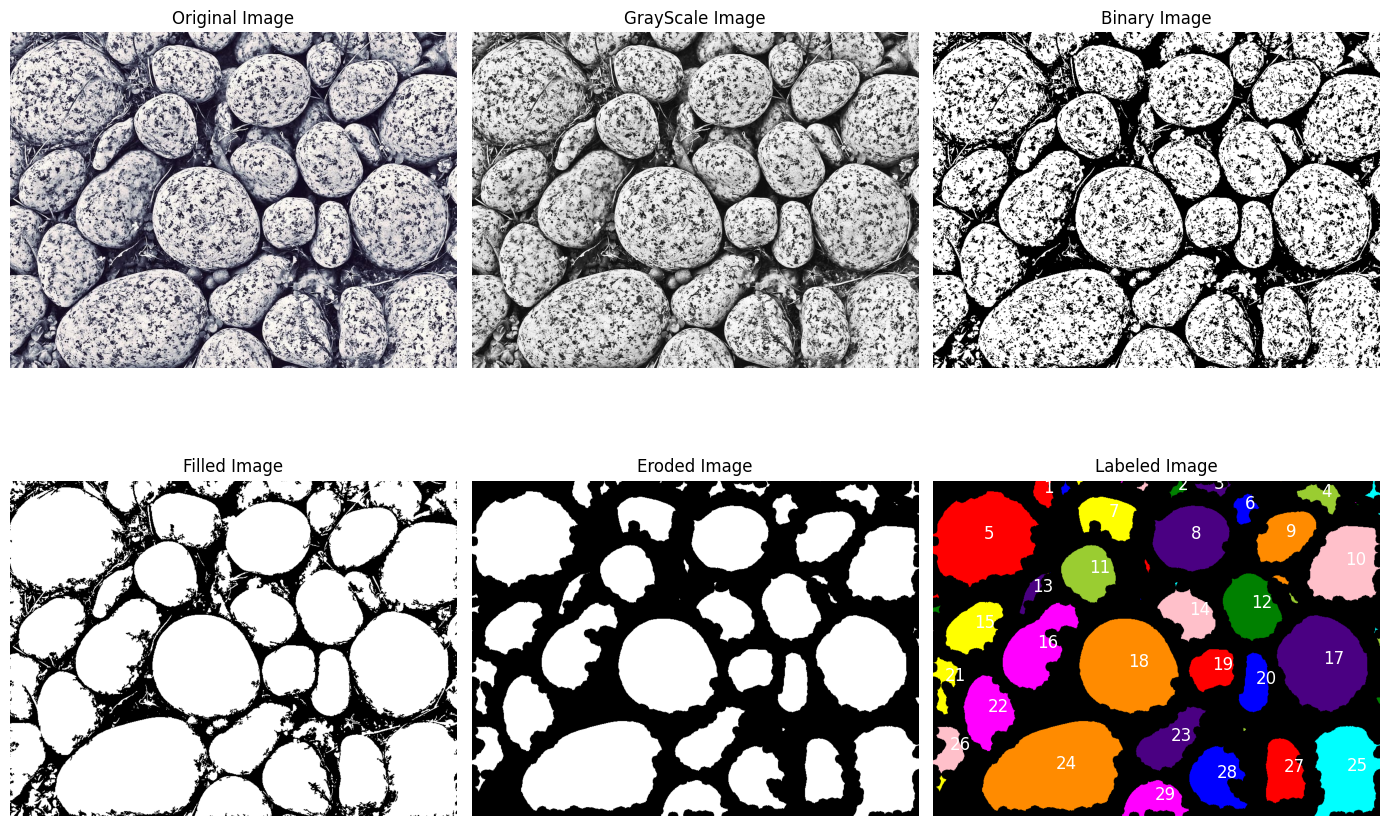

In [7]:
from scipy.ndimage import binary_fill_holes

#Ex7_4: Region labelling
Img = cv2.imread(PATH + 'stones.jpg', cv2.IMREAD_COLOR_RGB)

# Convert from RGB to GRAYSCALE
Img_gray = cv2.cvtColor(Img, cv2.COLOR_RGB2GRAY)

# Convert from GRAYSCALE to BINARY
_, Img_bw = cv2.threshold(Img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Label regions in the binary image
L = label(Img_bw, connectivity=2)
regions = regionprops(L)
print(f'Number of stones before processing: {len(regions)}')

# Fill holes in the binary image
Img_filled = binary_fill_holes(Img_bw)

# Perform erosion on the filled image to elimate small regions
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
Img_eroded = cv2.erode(Img_filled.astype(np.uint8), se, iterations=2)

# Count number of stones before being processed
L = label(Img_eroded, connectivity=2)
regions = regionprops(L)
print(f'Number of stones after this step: {len(regions): .0f}')

# Filter stones based on region size
min_area = 500
stones = [r for r in regions if r.area >= min_area]
print(f'Number of stones after processing: {len(stones)}')

# Label stones
L = label(Img_eroded, connectivity=2)
Img_label = label2rgb(L, bg_label=0, bg_color=(0,0,0), kind='overlay')

# Display results
plt.figure(figsize=(14, 10))

plt.subplot(2,3,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS)
plt.axis('off')
plt.subplot(2,3,2), plt.imshow(Img_gray, cmap='gray'), plt.title('GrayScale Image', fontsize=FS)
plt.axis('off')
plt.subplot(2,3,3), plt.imshow(Img_bw, cmap='gray'), plt.title('Binary Image', fontsize=FS)
plt.axis('off')
plt.subplot(2,3,4), plt.imshow(Img_filled, cmap='gray'), plt.title('Filled Image', fontsize=FS)
plt.axis('off')
plt.subplot(2,3,5), plt.imshow(Img_eroded, cmap='gray'), plt.title('Eroded Image', fontsize=FS)
plt.axis('off')
plt.subplot(2,3,6), plt.imshow(Img_label, cmap='gray'), plt.title('Labeled Image', fontsize=FS)
plt.axis('off')

#number stones
for i, r in enumerate(stones):
  plt.annotate(f'{i+1}', (r.centroid[1], r.centroid[0]), fontsize=FS,color='white')

plt.tight_layout()
plt.savefig(PATH + 'Ex7_4.jpg', dpi=400)
plt.show()